# Synthetic Banking A/B Testing — Experiment Analysis

This notebook estimates treatment effects for three pre-registered experiments. Primary metrics are evaluated first. Holm correction is applied only to each experiment's secondary metric family; guardrails are evaluated against pre-specified business thresholds.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from experiment_statistics import (
    bootstrap_mean_difference,
    cuped_adjust,
    holm_adjust,
    proportion_effect,
    srm_test,
    welch_mean_effect,
)

with (ROOT / "config" / "experiment_config.yml").open(encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

PROJECT = CONFIG["project"]
EXPERIMENTS = CONFIG["experiments"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

datasets = {
    experiment_id: pd.read_csv(ROOT / experiment["output_file"])
    for experiment_id, experiment in EXPERIMENTS.items()
}

design_path = ROOT / "results" / "design_summary.csv"
if not design_path.exists():
    raise FileNotFoundError(
        "Run notebooks/01_experiment_design.ipynb before this notebook."
    )
design_summary = pd.read_csv(design_path).set_index("experiment_id")

## Analysis gate

An experiment with sample-ratio mismatch or unacceptable pre-treatment imbalance is not analysed. Insufficient power does not invalidate assignment, but it forces an `INCONCLUSIVE` business decision.

In [2]:
invalid = design_summary.loc[~design_summary["analysis_valid"].astype(bool)]
if not invalid.empty:
    raise RuntimeError(
        "Assignment validation failed for: "
        + ", ".join(invalid.index.tolist())
    )

print("All experiments passed the assignment and balance analysis gate.")

All experiments passed the assignment and balance analysis gate.


## EXP-01 — Live FX Spread Discount

In [3]:
fx = datasets["EXP-01"].copy()

raw_fx_primary = welch_mean_effect(
    fx,
    "outcome_revenue_usd",
    PROJECT["alpha"],
)
raw_bootstrap_ci = bootstrap_mean_difference(
    fx,
    "outcome_revenue_usd",
    confidence_level=PROJECT["confidence_level"],
    n_resamples=PROJECT["bootstrap_resamples"],
    random_seed=EXPERIMENTS["EXP-01"]["random_seed"] + 101,
)

fx["outcome_revenue_usd_cuped"], cuped_theta, variance_reduction = cuped_adjust(
    fx["outcome_revenue_usd"],
    fx["prior_fx_revenue_usd"],
)
cuped_fx_primary = welch_mean_effect(
    fx,
    "outcome_revenue_usd_cuped",
    PROJECT["alpha"],
)
cuped_bootstrap_ci = bootstrap_mean_difference(
    fx,
    "outcome_revenue_usd_cuped",
    confidence_level=PROJECT["confidence_level"],
    n_resamples=PROJECT["bootstrap_resamples"],
    random_seed=EXPERIMENTS["EXP-01"]["random_seed"] + 102,
)

fx_primary_table = pd.DataFrame(
    [
        {
            **raw_fx_primary.to_dict(),
            "analysis": "raw",
            "bootstrap_ci_low": raw_bootstrap_ci[0],
            "bootstrap_ci_high": raw_bootstrap_ci[1],
            "cuped_theta": np.nan,
            "variance_reduction": np.nan,
        },
        {
            **cuped_fx_primary.to_dict(),
            "analysis": "pre-specified CUPED",
            "bootstrap_ci_low": cuped_bootstrap_ci[0],
            "bootstrap_ci_high": cuped_bootstrap_ci[1],
            "cuped_theta": cuped_theta,
            "variance_reduction": variance_reduction,
        },
    ]
)
fx_primary_table

,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,analysis,bootstrap_ci_low,bootstrap_ci_high,cuped_theta,variance_reduction
0,outcome_revenue_usd,"9,234.0010","8,448.7649",-785.2361,-0.0850,"-1,350.7009",-219.7714,0.0065,Welch unequal-variance t-test,raw,"-1,337.1280",-194.8572,NaN,NaN
1,outcome_revenue_usd_cuped,"9,078.0587","8,604.6947",-473.3640,-0.0521,-784.0407,-162.6874,0.0028,Welch unequal-variance t-test,pre-specified CUPED,-761.1731,-175.4259,0.3332,0.6981


In [4]:
fx_secondary_results = [
    proportion_effect(fx, "outcome_fx_conversion", PROJECT["alpha"]),
    welch_mean_effect(fx, "outcome_transaction_count", PROJECT["alpha"]),
    welch_mean_effect(fx, "outcome_turnover_usd", PROJECT["alpha"]),
]
fx_secondary_table = pd.DataFrame(
    [result.to_dict() for result in fx_secondary_results]
)
fx_secondary_table["p_value_holm"] = holm_adjust(
    fx_secondary_table["p_value"],
    PROJECT["alpha"],
)

fx_completed = fx.loc[fx["outcome_transaction_count"] > 0]
fx_diagnostics = pd.DataFrame(
    [
        welch_mean_effect(
            fx_completed,
            "outcome_revenue_per_transaction_usd",
            PROJECT["alpha"],
        ).to_dict(),
        welch_mean_effect(
            fx,
            "outcome_effective_spread",
            PROJECT["alpha"],
        ).to_dict(),
    ]
)

display(fx_secondary_table)
display(fx_diagnostics)

,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,p_value_holm
0,outcome_fx_conversion,0.7925,0.7988,0.0063,0.0080,-0.0007,0.0134,0.0789,two-sample score test for proportions,0.1578
1,outcome_transaction_count,4.2101,4.4675,0.2575,0.0612,0.1871,0.3278,0.0000,Welch unequal-variance t-test,0.0000
2,outcome_turnover_usd,"4,995,965.2698","5,009,144.5047","13,179.2349",0.0026,"-282,423.7658","308,782.2356",0.9304,Welch unequal-variance t-test,0.9304


,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method
0,outcome_revenue_per_transaction_usd,"2,261.3545","1,883.5846",-377.7700,-0.1671,-569.6958,-185.8441,0.0001,Welch unequal-variance t-test
1,outcome_effective_spread,0.0043,0.0040,-0.0004,-0.0820,-0.0004,-0.0003,0.0000,Welch unequal-variance t-test


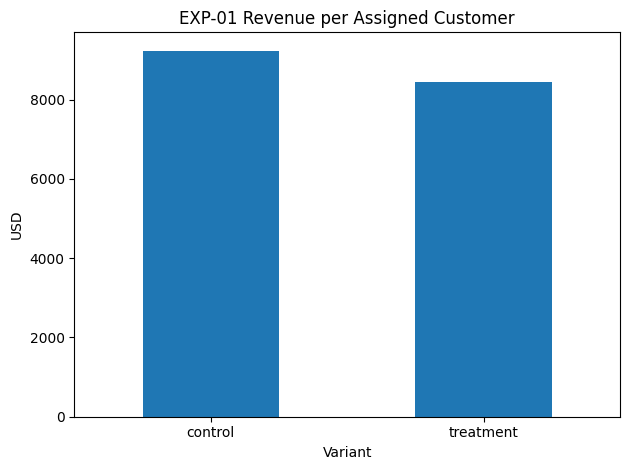

In [5]:
fx.groupby("variant")["outcome_revenue_usd"].mean().plot(
    kind="bar",
    title="EXP-01 Revenue per Assigned Customer",
    ylabel="USD",
    xlabel="Variant",
    rot=0,
)
plt.tight_layout()
plt.show()

## EXP-02 — DCD Cross-Sell Outreach

In [6]:
dcd = datasets["EXP-02"].copy()

dcd_primary = proportion_effect(
    dcd,
    "outcome_dcd_conversion",
    PROJECT["alpha"],
)
dcd_fee_revenue = welch_mean_effect(
    dcd,
    "outcome_fee_revenue_usd",
    PROJECT["alpha"],
)
dcd_fee_revenue_ci = bootstrap_mean_difference(
    dcd,
    "outcome_fee_revenue_usd",
    confidence_level=PROJECT["confidence_level"],
    n_resamples=PROJECT["bootstrap_resamples"],
    random_seed=EXPERIMENTS["EXP-02"]["random_seed"] + 201,
)
dcd_fx_guardrail = welch_mean_effect(
    dcd,
    "outcome_fx_revenue_usd",
    PROJECT["alpha"],
)
dcd_fx_guardrail_ci = bootstrap_mean_difference(
    dcd,
    "outcome_fx_revenue_usd",
    confidence_level=PROJECT["confidence_level"],
    n_resamples=PROJECT["bootstrap_resamples"],
    random_seed=EXPERIMENTS["EXP-02"]["random_seed"] + 202,
)

dcd_secondary_table = pd.DataFrame(
    [{**dcd_fee_revenue.to_dict(), "p_value_holm": dcd_fee_revenue.p_value}]
)
dcd_guardrail_table = pd.DataFrame(
    [
        {
            **dcd_fx_guardrail.to_dict(),
            "bootstrap_ci_low": dcd_fx_guardrail_ci[0],
            "bootstrap_ci_high": dcd_fx_guardrail_ci[1],
        }
    ]
)

display(pd.DataFrame([dcd_primary.to_dict()]))
display(dcd_secondary_table)
display(dcd_guardrail_table)

,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method
0,outcome_dcd_conversion,0.1289,0.1558,0.0268,0.2081,0.0034,0.0502,0.0245,two-sample score test for proportions


,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,p_value_holm
0,outcome_fee_revenue_usd,136.1854,156.1450,19.9596,0.1466,-26.9300,66.8492,0.4040,Welch unequal-variance t-test,0.4040


,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,bootstrap_ci_low,bootstrap_ci_high
0,outcome_fx_revenue_usd,"9,588.5037","9,355.1565",-233.3472,-0.0243,"-1,874.4732","1,407.7788",0.7804,Welch unequal-variance t-test,"-1,824.5133","1,500.1533"


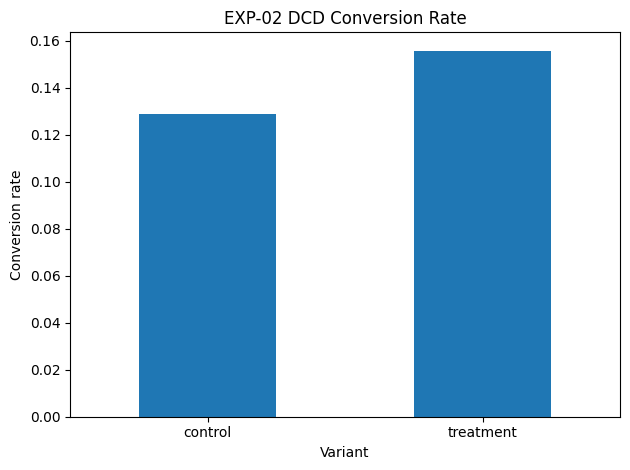

In [7]:
dcd.groupby("variant")["outcome_dcd_conversion"].mean().plot(
    kind="bar",
    title="EXP-02 DCD Conversion Rate",
    ylabel="Conversion rate",
    xlabel="Variant",
    rot=0,
)
plt.tight_layout()
plt.show()

## EXP-03 — Digital Channel Migration

In [8]:
digital = datasets["EXP-03"].copy()

digital_primary = proportion_effect(
    digital,
    "outcome_digital_adoption",
    PROJECT["alpha"],
)
digital_secondary_results = [
    welch_mean_effect(
        digital,
        "outcome_digital_share",
        PROJECT["alpha"],
    ),
    welch_mean_effect(
        digital,
        "outcome_transaction_count",
        PROJECT["alpha"],
    ),
]
digital_secondary_table = pd.DataFrame(
    [result.to_dict() for result in digital_secondary_results]
)
digital_secondary_table["p_value_holm"] = holm_adjust(
    digital_secondary_table["p_value"],
    PROJECT["alpha"],
)

digital_revenue = welch_mean_effect(
    digital,
    "outcome_revenue_usd",
    PROJECT["alpha"],
)
digital_revenue_ci = bootstrap_mean_difference(
    digital,
    "outcome_revenue_usd",
    confidence_level=PROJECT["confidence_level"],
    n_resamples=PROJECT["bootstrap_resamples"],
    random_seed=EXPERIMENTS["EXP-03"]["random_seed"] + 301,
)

display(pd.DataFrame([digital_primary.to_dict()]))
display(digital_secondary_table)
display(
    pd.DataFrame(
        [
            {
                **digital_revenue.to_dict(),
                "bootstrap_ci_low": digital_revenue_ci[0],
                "bootstrap_ci_high": digital_revenue_ci[1],
            }
        ]
    )
)

,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method
0,outcome_digital_adoption,0.7196,0.7421,0.0225,0.0313,-0.0088,0.0537,0.1587,two-sample score test for proportions


,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,p_value_holm
0,outcome_digital_share,0.5922,0.6115,0.0193,0.0326,-0.0089,0.0475,0.1797,Welch unequal-variance t-test,0.3594
1,outcome_transaction_count,10.5810,10.7369,0.1559,0.0147,-0.5560,0.8679,0.6677,Welch unequal-variance t-test,0.6677


,metric,control,treatment,absolute_effect,relative_lift,ci_low,ci_high,p_value,method,bootstrap_ci_low,bootstrap_ci_high
0,outcome_revenue_usd,"15,314.3915","16,982.5106","1,668.1191",0.1089,"-2,889.8109","6,226.0491",0.4730,Welch unequal-variance t-test,"-3,279.9595","6,077.7521"


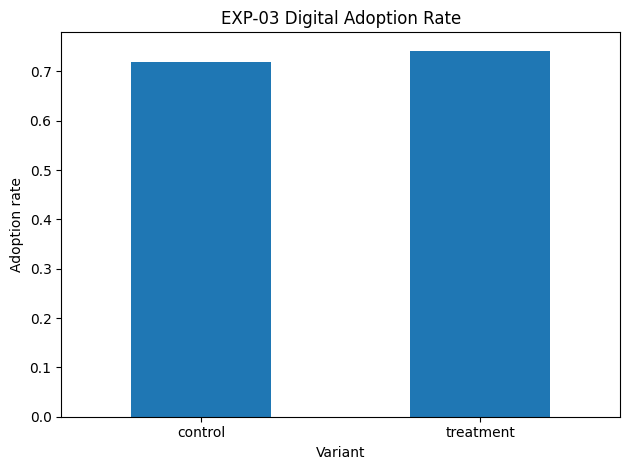

In [9]:
digital.groupby("variant")["outcome_digital_adoption"].mean().plot(
    kind="bar",
    title="EXP-03 Digital Adoption Rate",
    ylabel="Adoption rate",
    xlabel="Variant",
    rot=0,
)
plt.tight_layout()
plt.show()

## Pre-specified business decisions

Underpowered experiments are labelled `INCONCLUSIVE`. A sufficiently powered experiment receives `LAUNCH` only when the primary and guardrail criteria pass; otherwise it receives `DO NOT LAUNCH`.

In [10]:
def decision_ready(experiment_id):
    return bool(design_summary.loc[experiment_id, "decision_ready"])

def decide(experiment_id, launch_condition, launch_reason, reject_reason):
    if not decision_ready(experiment_id):
        return "INCONCLUSIVE", "Pre-specified sample requirement was not met."
    if launch_condition:
        return "LAUNCH", launch_reason
    return "DO NOT LAUNCH", reject_reason

fx_decision, fx_reason = decide(
    "EXP-01",
    cuped_fx_primary.absolute_effect > 0
    and cuped_fx_primary.p_value < PROJECT["alpha"],
    "The pre-specified CUPED revenue criterion passed.",
    "The pre-specified CUPED revenue criterion did not pass.",
)

dcd_control_fx_revenue = dcd_fx_guardrail.control
dcd_fx_relative_ci_low = (
    dcd_fx_guardrail_ci[0] / dcd_control_fx_revenue
    if dcd_control_fx_revenue != 0
    else np.nan
)
dcd_floor = EXPERIMENTS["EXP-02"]["fx_revenue_guardrail_relative_floor"]
dcd_decision, dcd_reason = decide(
    "EXP-02",
    dcd_primary.absolute_effect > 0
    and dcd_primary.p_value < PROJECT["alpha"]
    and dcd_fee_revenue.absolute_effect >= 0
    and dcd_fx_relative_ci_low > dcd_floor,
    "Conversion, fee revenue, and FX revenue guardrail criteria passed.",
    "At least one cross-sell decision criterion did not pass.",
)

digital_control_revenue = digital_revenue.control
digital_relative_ci_low = (
    digital_revenue_ci[0] / digital_control_revenue
    if digital_control_revenue != 0
    else np.nan
)
digital_floor = EXPERIMENTS["EXP-03"]["revenue_guardrail_relative_floor"]
digital_decision, digital_reason = decide(
    "EXP-03",
    digital_primary.absolute_effect > 0
    and digital_primary.p_value < PROJECT["alpha"]
    and digital_relative_ci_low > digital_floor,
    "Digital adoption and revenue guardrail criteria passed.",
    "Digital adoption or revenue guardrail criterion did not pass.",
)

decision_summary = pd.DataFrame(
    [
        {
            "experiment_id": "EXP-01",
            "primary_metric": "CUPED revenue per assigned customer",
            "absolute_effect": cuped_fx_primary.absolute_effect,
            "relative_lift": cuped_fx_primary.relative_lift,
            "p_value": cuped_fx_primary.p_value,
            "decision": fx_decision,
            "reason": fx_reason,
        },
        {
            "experiment_id": "EXP-02",
            "primary_metric": "DCD conversion rate",
            "absolute_effect": dcd_primary.absolute_effect,
            "relative_lift": dcd_primary.relative_lift,
            "p_value": dcd_primary.p_value,
            "decision": dcd_decision,
            "reason": dcd_reason,
        },
        {
            "experiment_id": "EXP-03",
            "primary_metric": "Digital adoption rate",
            "absolute_effect": digital_primary.absolute_effect,
            "relative_lift": digital_primary.relative_lift,
            "p_value": digital_primary.p_value,
            "decision": digital_decision,
            "reason": digital_reason,
        },
    ]
)
decision_summary

,experiment_id,primary_metric,absolute_effect,relative_lift,p_value,decision,reason
0,EXP-01,CUPED revenue per assigned customer,-473.3640,-0.0521,0.0028,DO NOT LAUNCH,The pre-specified CUPED revenue criterion did ...
1,EXP-02,DCD conversion rate,0.0268,0.2081,0.0245,INCONCLUSIVE,Pre-specified sample requirement was not met.
2,EXP-03,Digital adoption rate,0.0225,0.0313,0.1587,INCONCLUSIVE,Pre-specified sample requirement was not met.


In [11]:
result_rows = []

def add_result(experiment_id, role, result, adjusted_p_value=np.nan):
    row = result.to_dict()
    row["experiment_id"] = experiment_id
    row["metric_role"] = role
    row["p_value_holm"] = adjusted_p_value
    result_rows.append(row)

add_result("EXP-01", "primary", cuped_fx_primary)
for result, adjusted in zip(
    fx_secondary_results,
    fx_secondary_table["p_value_holm"],
):
    add_result("EXP-01", "secondary", result, adjusted)
for _, row in fx_diagnostics.iterrows():
    row_dict = row.to_dict()
    row_dict["experiment_id"] = "EXP-01"
    row_dict["metric_role"] = "diagnostic"
    row_dict["p_value_holm"] = np.nan
    result_rows.append(row_dict)

add_result("EXP-02", "primary", dcd_primary)
add_result("EXP-02", "secondary", dcd_fee_revenue, dcd_fee_revenue.p_value)
add_result("EXP-02", "guardrail", dcd_fx_guardrail)

add_result("EXP-03", "primary", digital_primary)
for result, adjusted in zip(
    digital_secondary_results,
    digital_secondary_table["p_value_holm"],
):
    add_result("EXP-03", "secondary", result, adjusted)
add_result("EXP-03", "guardrail", digital_revenue)

experiment_results = pd.DataFrame(result_rows)
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

experiment_results.to_csv(
    results_dir / "experiment_results.csv",
    index=False,
    encoding="utf-8-sig",
)
decision_summary.to_csv(
    results_dir / "decision_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

[
    (results_dir / "experiment_results.csv").relative_to(ROOT),
    (results_dir / "decision_summary.csv").relative_to(ROOT),
]

[WindowsPath('results/experiment_results.csv'),
 WindowsPath('results/decision_summary.csv')]

## Interpretation boundary

The estimates are causal within the generated randomised experiment layer. Historical banking data defines eligibility and baseline behaviour; it is not itself interpreted causally.